In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import joblib

In [2]:
df=pd.read_csv('train.csv') 
df.head(6)

C:\Users\HP\AppData\Local\Temp\ipykernel_15204\3556621970.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('train.csv')


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
5,6,5,2015-07-31,5651,589,1,1,0,1


In [3]:
df.isnull().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [45]:
df = df[['Date', 'Sales']]

In [46]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])

In [47]:
df = df[df['Sales'] > 0]

In [48]:
df=df.sort_values('Date')

In [49]:
df=df.reset_index(drop=True)

In [50]:
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['Weekday'] = df['Date'].dt.weekday

In [51]:
print(df.head(5))
print("Total rows:", len(df))

        Date  Sales  Day  Month  Weekday
0 2013-01-01   5961    1      1        1
1 2013-01-01   4220    1      1        1
2 2013-01-01   6851    1      1        1
3 2013-01-01   3102    1      1        1
4 2013-01-01   3139    1      1        1
Total rows: 810935


In [52]:
q_low = df['Sales'].quantile(0.01)
q_high = df['Sales'].quantile(0.99)

df = df[(df['Sales'] >= q_low) & (df['Sales'] <= q_high)]

print("Rows after outlier removal:", len(df))

Rows after outlier removal: 794736


In [53]:
features = ['Sales', 'Day', 'Month', 'Weekday']
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[features])

In [54]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [71]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X_baseline = df[['Day', 'Month', 'Weekday']]
y_baseline = df['Sales']

split_idx = int(0.8 * len(X_baseline))
X_train_b = X_baseline[:split_idx]
X_test_b = X_baseline[split_idx:]
y_train_b = y_baseline[:split_idx]
y_test_b = y_baseline[split_idx:]

lr = LinearRegression()
lr.fit(X_train_b, y_train_b)

y_pred_b = lr.predict(X_test_b)

rmse_baseline = np.sqrt(mean_squared_error(y_test_b, y_pred_b))
print("Baseline RMSE:", rmse_baseline)

Baseline RMSE: 2375.971466774475


In [57]:
sequence_length = 30

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i][0])  # only Sales target

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (794706, 30, 4)
y shape: (794706,)


In [58]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (635764, 30, 4)
Test shape: (158942, 30, 4)


In [59]:
from tensorflow.keras.layers import Dropout, Input

model = Sequential()

model.add(Input(shape=(X.shape[1], X.shape[2])))
model.add(LSTM(100, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(100))
model.add(Dropout(0.2))
model.add(Dense(1))

In [60]:
model.compile(
    optimizer='adam',
    loss='mse'
)

In [61]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,    
    validation_split=0.1
)

Epoch 1/10
17881/17881 ━━━━━━━━━━━━━━━━━━━━ 579s 32ms/step - loss: 0.0345 - val_loss: 0.0365
Epoch 2/10
17881/17881 ━━━━━━━━━━━━━━━━━━━━ 567s 32ms/step - loss: 0.0339 - val_loss: 0.0365
Epoch 3/10
17881/17881 ━━━━━━━━━━━━━━━━━━━━ 557s 31ms/step - loss: 0.0338 - val_loss: 0.0365
Epoch 4/10
17881/17881 ━━━━━━━━━━━━━━━━━━━━ 539s 30ms/step - loss: 0.0337 - val_loss: 0.0371
Epoch 5/10
17881/17881 ━━━━━━━━━━━━━━━━━━━━ 660s 37ms/step - loss: 0.0336 - val_loss: 0.0362
Epoch 6/10
17881/17881 ━━━━━━━━━━━━━━━━━━━━ 700s 39ms/step - loss: 0.0336 - val_loss: 0.0361
Epoch 7/10
17881/17881 ━━━━━━━━━━━━━━━━━━━━ 696s 39ms/step - loss: 0.0335 - val_loss: 0.0359
Epoch 8/10
17881/17881 ━━━━━━━━━━━━━━━━━━━━ 676s 38ms/step - loss: 0.0335 - val_loss: 0.0361
Epoch 9/10
17881/17881 ━━━━━━━━━━━━━━━━━━━━ 719s 40ms/step - loss: 0.0334 - val_loss: 0.0362
Epoch 10/10
17881/17881 ━━━━━━━━━━━━━━━━━━━━ 718s 40ms/step - loss: 0.0334 - val_loss: 0.0362


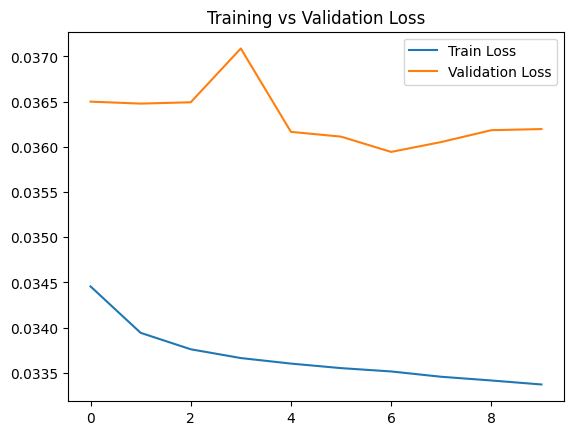

In [62]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()   

In [63]:
predictions = model.predict(X_test)

4967/4967 ━━━━━━━━━━━━━━━━━━━━ 66s 13ms/step


In [66]:
num_features = 4

dummy_pred = np.zeros((len(predictions), num_features))
dummy_pred[:, 0] = predictions.flatten ()

dummy_actual = np.zeros((len(y_test), num_features))
dummy_actual[:, 0] = y_test.flatten()

predictions_actual = scaler.inverse_transform(dummy_pred)[:, 0]
y_test_actual = scaler.inverse_transform(dummy_actual)[:, 0]

In [67]:
print("Average sales:", df['Sales'].mean())

Average sales: 6774.436498409535


In [68]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_actual, predictions_actual))
print("RMSE:", rmse)

RMSE: 2122.7291951246966


In [69]:
error_percentage = (rmse / df['Sales'].mean()) * 100
print("Error %:", error_percentage)

Error %: 31.334402435140685


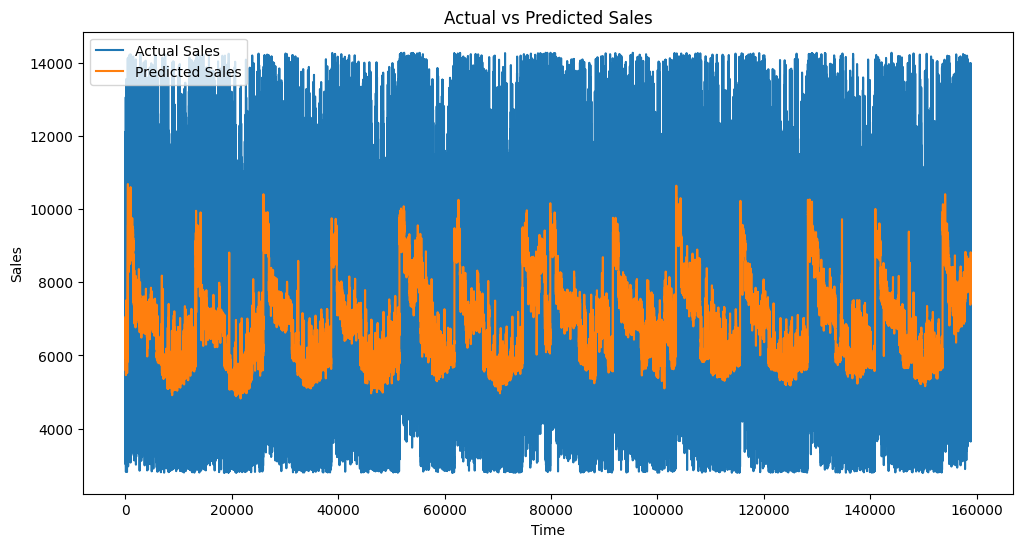

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label='Actual Sales')
plt.plot(predictions_actual, label='Predicted Sales')

plt.title("Actual vs Predicted Sales")
plt.xlabel("Time")
plt.ylabel("Sales")

plt.legend()
plt.show()

In [72]:
model.save("lstm_model.keras")

In [34]:
def predict_future(model,last_sequence,steps=7):
    future=[]
    current=last_sequence.copy()
    for _ in range(steps):
        pred=model.predict(current.reshape(1,-1,1))
        future.append(pred[0][0])
        current = np.append(current[1:], pred[0][0])
    return future